In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [15]:
path_test = "C:/Users/Ihab/Desktop/Preprocessing/test.csv"
path_train = "C:/Users/Ihab/Desktop/Preprocessing/train.csv"
train = pd.read_csv(path_train)
test = pd.read_csv(path_test)

In [16]:
(train.isnull().sum()/len(train))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

<Axes: >

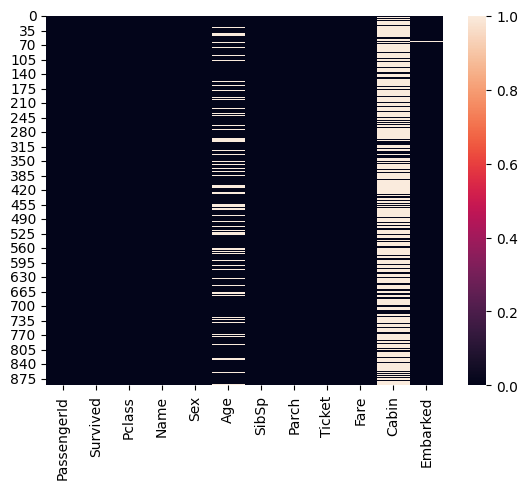

In [17]:
sns.heatmap(train.isnull())

In [18]:
train.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [19]:
train.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [20]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
train['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [98]:
train.duplicated().sum()
test.duplicated().sum()

0

In [23]:
v = train.select_dtypes(include='number').corr()
v

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

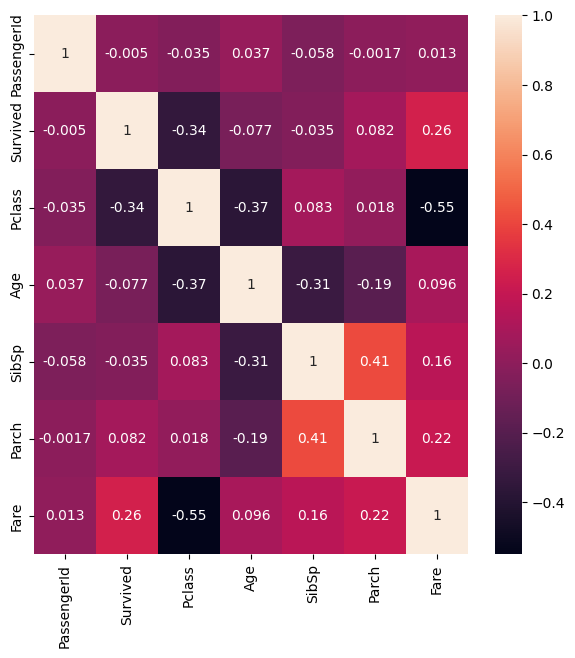

In [30]:
plt.figure(figsize = (7,7))
sns.heatmap(v,annot=True)

In [99]:
dummy = pd.get_dummies(data=train,columns=['Sex','Embarked'],drop_first=True)
dummy2 = pd.get_dummies(data=test,columns=['Sex','Embarked'],drop_first=True)

In [100]:
dummy


,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,NaN,True,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,NaN,False,False,True
2,894,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,NaN,True,True,False
3,895,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,NaN,True,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",NaN,0,0,A.5. 3236,8.0500,NaN,True,False,True
414,1306,1,"Oliva y Ocana, Dona. Fermina",39.0,0,0,PC 17758,108.9000,C105,False,False,False
415,1307,3,"Saether, Mr. Simon Sivertsen",38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,True,False,True
416,1308,3,"Ware, Mr. Frederick",NaN,0,0,359309,8.0500,NaN,True,False,True


In [101]:
dummy2

,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,NaN,True,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,NaN,False,False,True
2,894,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,NaN,True,True,False
3,895,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,NaN,True,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",NaN,0,0,A.5. 3236,8.0500,NaN,True,False,True
414,1306,1,"Oliva y Ocana, Dona. Fermina",39.0,0,0,PC 17758,108.9000,C105,False,False,False
415,1307,3,"Saether, Mr. Simon Sivertsen",38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,True,False,True
416,1308,3,"Ware, Mr. Frederick",NaN,0,0,359309,8.0500,NaN,True,False,True


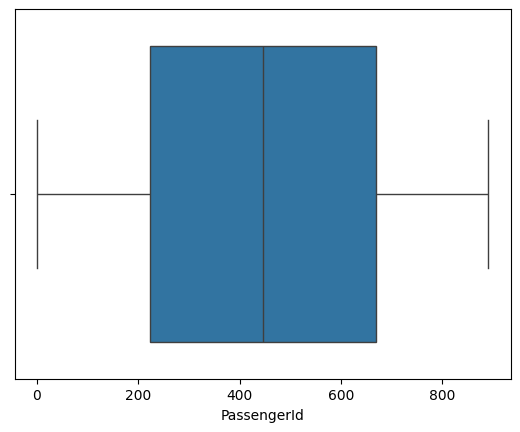

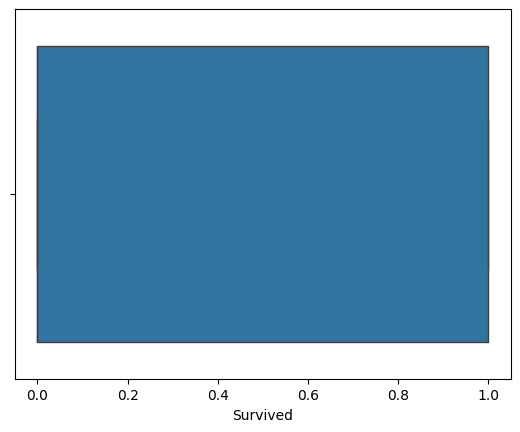

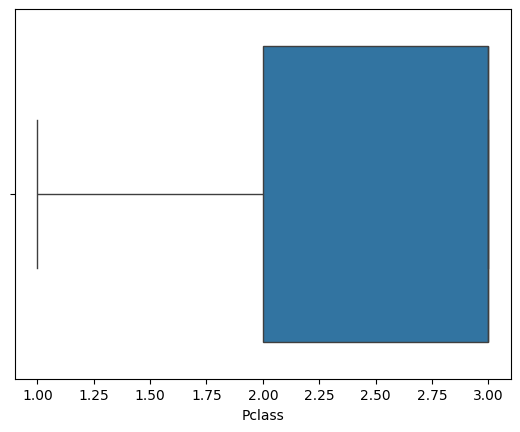

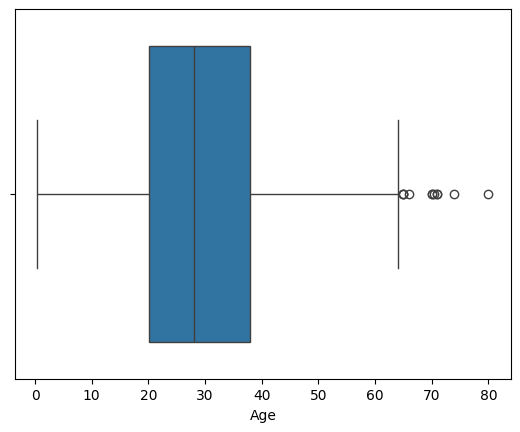

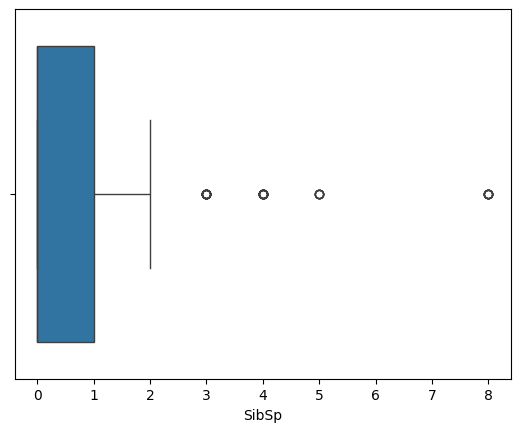

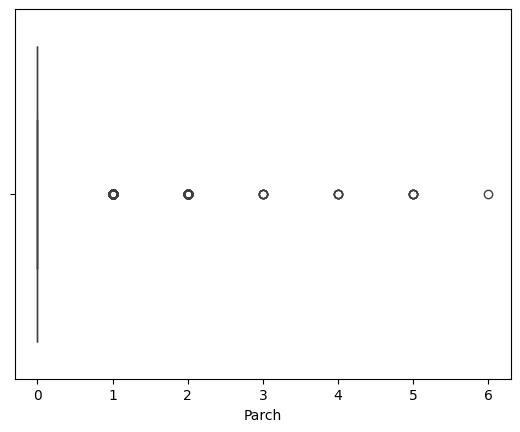

In [36]:
for i in train.select_dtypes(include='number').columns:
    sns.boxplot(data=train,x=i)
    plt.show()

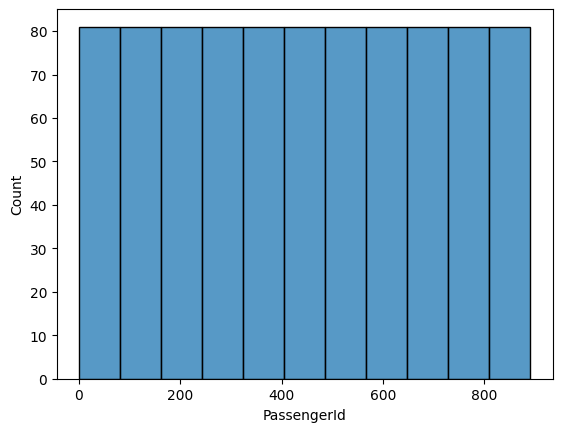

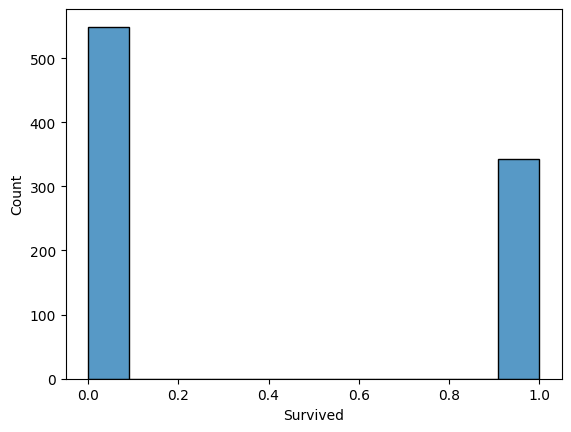

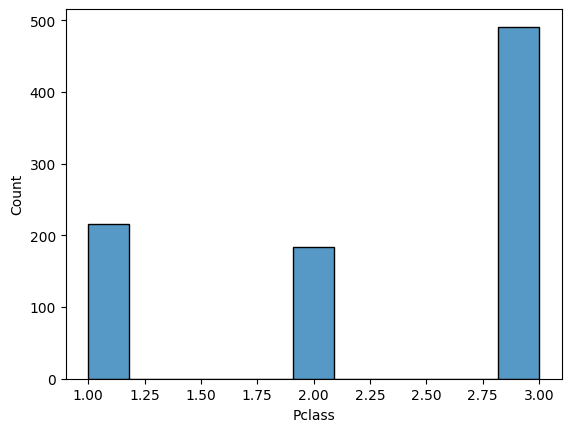

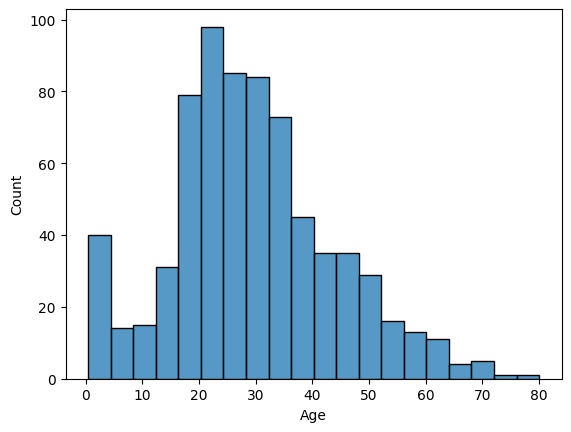

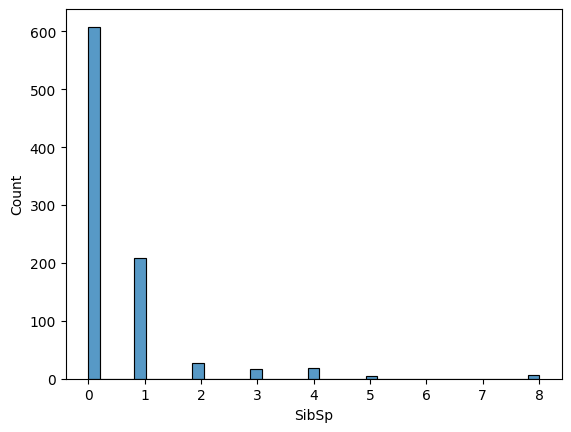

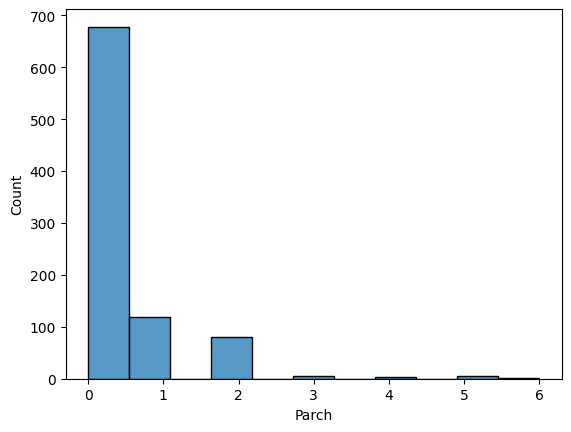

In [37]:
for i in train.select_dtypes(include='number').columns:
    sns.histplot(data=train,x=i)
    plt.show()

In [38]:
for i in ["Age"]:
    train[i].fillna(train[i].median(),inplace=True)

In [102]:
for i in ["Age"]:
    test[i].fillna(test[i].median(),inplace=True)

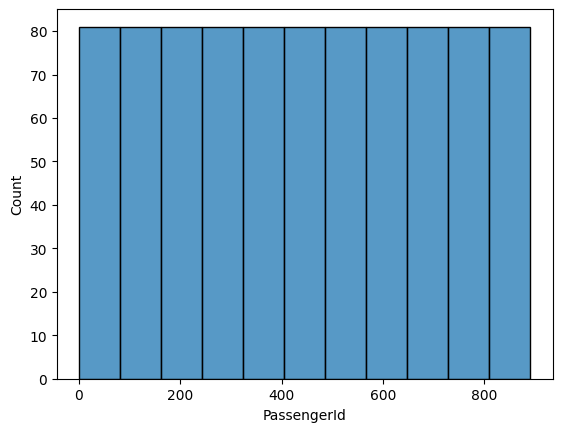

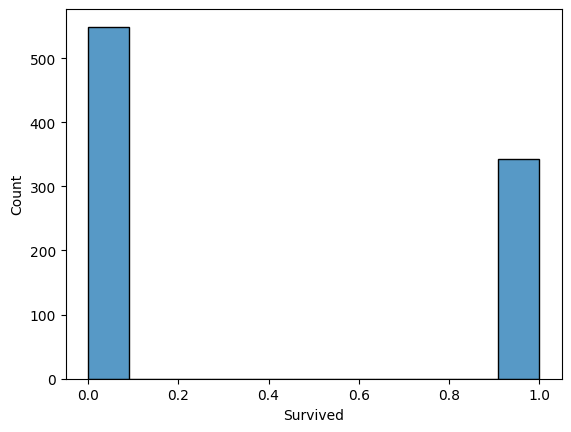

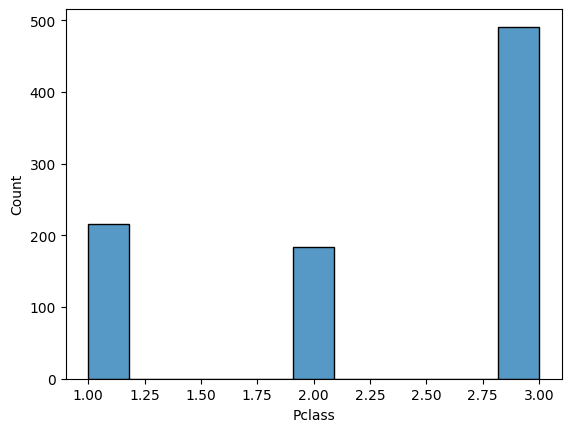

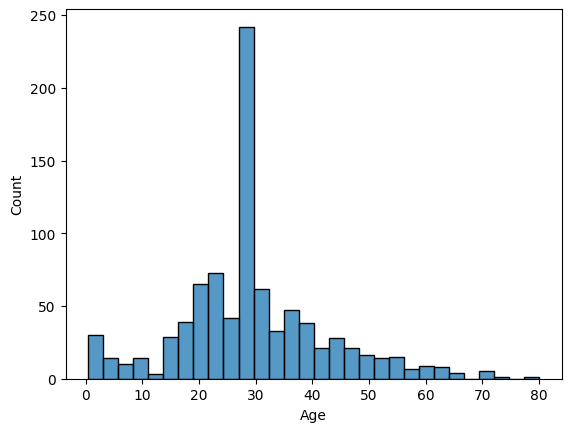

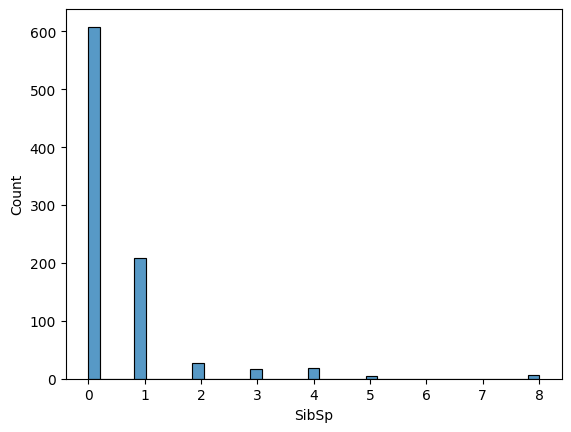

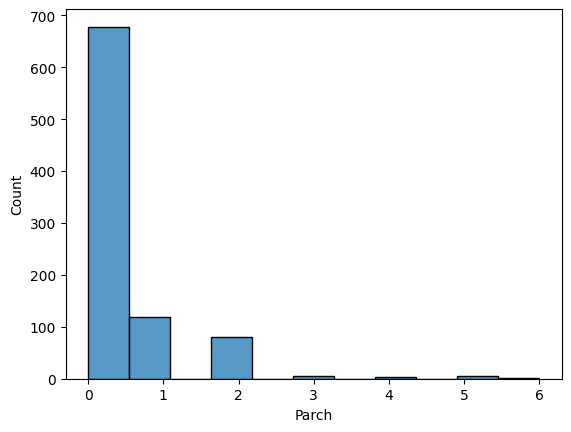

In [40]:
for i in train.select_dtypes(include='number').columns:
    sns.histplot(data=train,x=i)
    plt.show()

In [41]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Embarked       2
dtype: int64

In [45]:
from sklearn.impute import KNNImputer
impute = KNNImputer()

In [46]:
for i in train.select_dtypes(include = 'number').columns:
    train[i] = impute.fit_transform(train[[i]])

In [47]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Embarked       2
dtype: int64

In [49]:
train.dropna()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,1.0,0.0,3.0,male,22.0,1.0,0.0,S
1,2.0,1.0,1.0,female,38.0,1.0,0.0,C
2,3.0,1.0,3.0,female,26.0,0.0,0.0,S
3,4.0,1.0,1.0,female,35.0,1.0,0.0,S
4,5.0,0.0,3.0,male,35.0,0.0,0.0,S
...,...,...,...,...,...,...,...,...
886,887.0,0.0,2.0,male,27.0,0.0,0.0,S
887,888.0,1.0,1.0,female,19.0,0.0,0.0,S
888,889.0,0.0,3.0,female,28.0,1.0,2.0,S
889,890.0,1.0,1.0,male,26.0,0.0,0.0,C


In [50]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Embarked       2
dtype: int64

<Axes: >

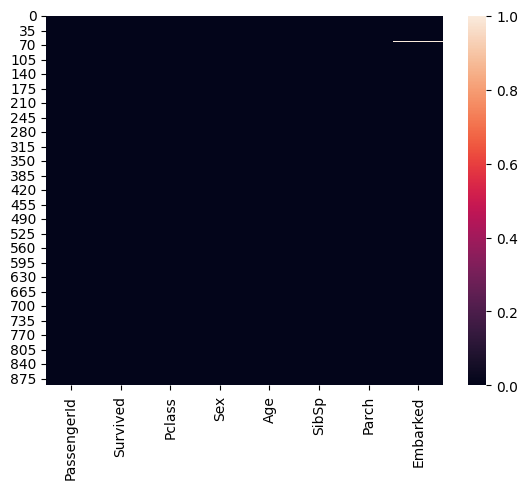

In [51]:
sns.heatmap(train.isnull())

In [52]:
train.dropna(axis=0)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,1.0,0.0,3.0,male,22.0,1.0,0.0,S
1,2.0,1.0,1.0,female,38.0,1.0,0.0,C
2,3.0,1.0,3.0,female,26.0,0.0,0.0,S
3,4.0,1.0,1.0,female,35.0,1.0,0.0,S
4,5.0,0.0,3.0,male,35.0,0.0,0.0,S
...,...,...,...,...,...,...,...,...
886,887.0,0.0,2.0,male,27.0,0.0,0.0,S
887,888.0,1.0,1.0,female,19.0,0.0,0.0,S
888,889.0,0.0,3.0,female,28.0,1.0,2.0,S
889,890.0,1.0,1.0,male,26.0,0.0,0.0,C


<Axes: >

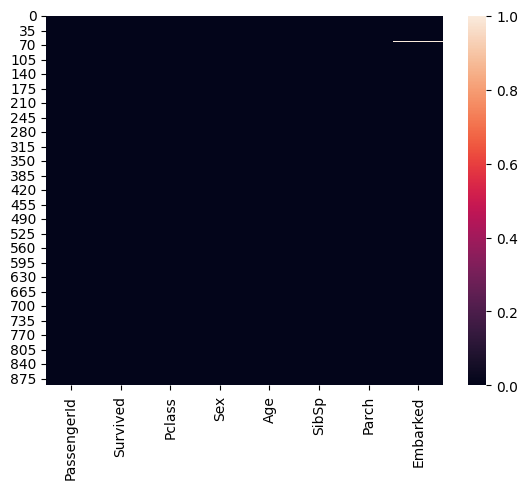

In [53]:
sns.heatmap(train.isnull())

In [55]:
mask = train['Embarked'].isnull()

In [103]:
mask2 = test['Embarked'].isnull()

In [104]:
df_clean = train[~mask]

In [105]:
df_clean2 = test[~mask2]

<Axes: xlabel='Sex', ylabel='count'>

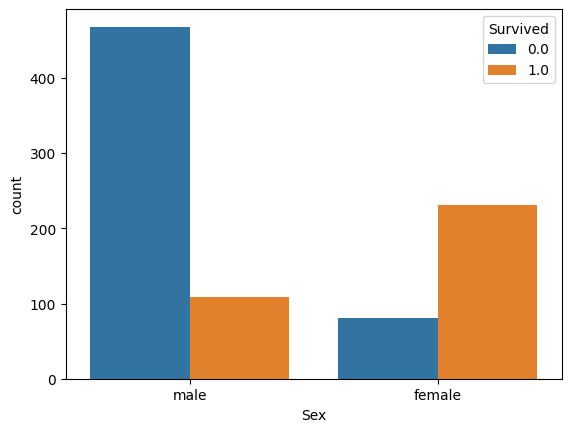

In [87]:
df_clean
sns.countplot(df_clean,x='Sex',hue='Survived')
sns.countplot(df_clean, x='Pclass', hue='Survived')              
sns.countplot(df_clean.Age, hue=df_clean.Survived)
sns.countplot(new_df.SibSp, hue=df_clean.Survived)
sns.countplot(new_df.Parch, hue=df_clean.Survived)
sns.countplot(new_df.Embarked, hue=df_clean.Survived)

<Axes: xlabel='Pclass', ylabel='count'>

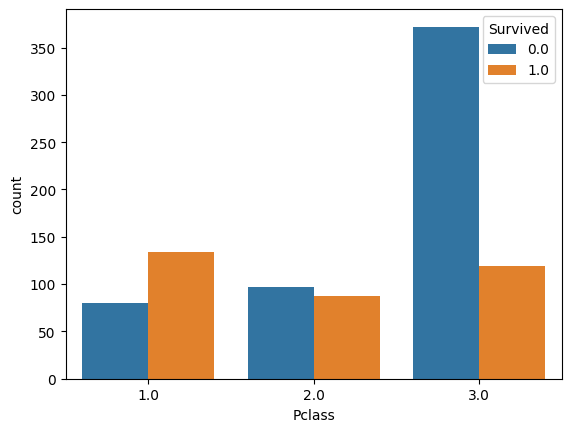

In [88]:
sns.countplot(df_clean, x='Pclass', hue='Survived')  

<Axes: xlabel='Age', ylabel='count'>

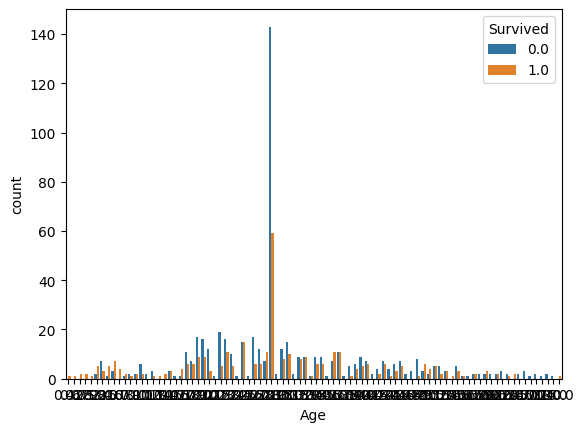

In [89]:
sns.countplot(df_clean, x='Age', hue='Survived')

<Axes: xlabel='Embarked', ylabel='count'>

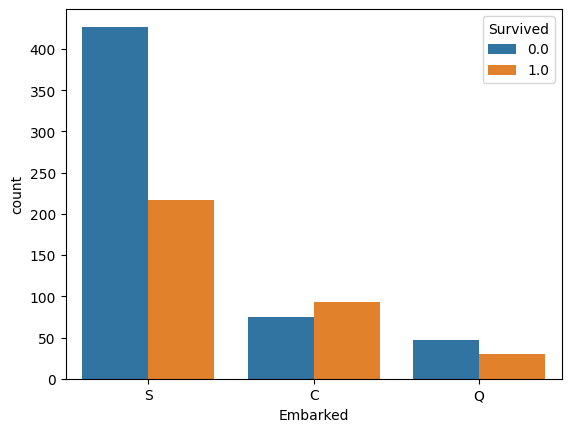

In [90]:
sns.countplot(df_clean, x='Embarked', hue='Survived')

In [106]:
df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Embarked       0
dtype: int64

In [107]:
df_clean2.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [108]:
new_df = pd.get_dummies(data=df_clean,columns=['Sex','Embarked'])

In [109]:
new_df2 = pd.get_dummies(data=df_clean2,columns=['Sex','Embarked'])

In [110]:
new_df.head(10)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1.0,0.0,3.0,22.0,1.0,0.0,False,True,False,False,True
1,2.0,1.0,1.0,38.0,1.0,0.0,True,False,True,False,False
2,3.0,1.0,3.0,26.0,0.0,0.0,True,False,False,False,True
3,4.0,1.0,1.0,35.0,1.0,0.0,True,False,False,False,True
4,5.0,0.0,3.0,35.0,0.0,0.0,False,True,False,False,True
5,6.0,0.0,3.0,28.0,0.0,0.0,False,True,False,True,False
6,7.0,0.0,1.0,54.0,0.0,0.0,False,True,False,False,True
7,8.0,0.0,3.0,2.0,3.0,1.0,False,True,False,False,True
8,9.0,1.0,3.0,27.0,0.0,2.0,True,False,False,False,True
9,10.0,1.0,2.0,14.0,1.0,0.0,True,False,True,False,False


In [111]:
new_df2.head(10)

,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,NaN,False,True,False,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,NaN,True,False,False,False,True
2,894,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,NaN,False,True,False,True,False
3,895,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,NaN,False,True,False,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,NaN,True,False,False,False,True
5,897,3,"Svensson, Mr. Johan Cervin",14.0,0,0,7538,9.2250,NaN,False,True,False,False,True
6,898,3,"Connolly, Miss. Kate",30.0,0,0,330972,7.6292,NaN,True,False,False,True,False
7,899,2,"Caldwell, Mr. Albert Francis",26.0,1,1,248738,29.0000,NaN,False,True,False,False,True
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",18.0,0,0,2657,7.2292,NaN,True,False,True,False,False
9,901,3,"Davies, Mr. John Samuel",21.0,2,0,A/4 48871,24.1500,NaN,False,True,False,False,True


In [126]:
df_2 = new_df2.drop(['Name','Ticket','Fare','Cabin'],axis='columns')

In [127]:
x = new_df.drop(['Survived'],axis = 1)
y = new_df.Survived
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=.8)
accuracies = []

In [128]:
def all(model):
    model.fit(x_train,y_train)
    pre = model.predict(x_train)
    accuracy = accuracy_score(pre,y_train)
    print("Accuracy is " ,accuracy)
    accuracies.append(accuracy)

In [129]:
model1=SVC()
model2=GaussianNB()
model3=DecisionTreeClassifier()
model4 = GradientBoostingClassifier()
model5 = KNeighborsClassifier()
model6 = RandomForestClassifier()
model7 = LogisticRegression()

In [130]:
all(model1)
all(model2)
all(model3)
all(model4)
all(model5)
all(model6)
all(model7)

Accuracy is  0.6216596343178622
Accuracy is  0.8045007032348804
Accuracy is  1.0
Accuracy is  0.9142053445850914
Accuracy is  0.6947960618846695
Accuracy is  1.0
Accuracy is  0.8115330520393812


c:\users\ihab\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [131]:
modelv2 = RandomForestClassifier()
modelv2.fit(x_train,y_train)

RandomForestClassifier()

In [133]:
rfc = modelv2.predict(df_2)

In [135]:
final = df_2.PassengerId
dernier_df = pd.DataFrame({'PassengerId':final,'Survived':rfc})
dernier_df.to_csv('submission.csv',index=False)